# EDA 13 - Product Concentration and Pareto Analysis

This notebook analyzes product revenue concentration, Pareto contribution, top-product stability over time, long-tail behavior, and leakage-safe product-concentration forecast feature examples using `orders.csv`, `order_items.csv`, and `products.csv`.

## 1. Setup and file discovery

Locate the required CSV files recursively from the current working directory and configure common analysis settings. Outputs are displayed directly in the notebook and are not saved to separate files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 280)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
REQUIRED_FILES = ["orders.csv", "order_items.csv", "products.csv"]
TOP_N_PRODUCTS_FOR_CHARTS = 20
TOP_N_PRODUCTS_FOR_TRENDS = 10

warning_messages = []
loaded_files = {}
file_paths = {}
analysis_ready = False

product_items = pd.DataFrame()
product_revenue = pd.DataFrame()
pareto_summary_df = pd.DataFrame()
concentration_metrics_df = pd.DataFrame()
monthly_product = pd.DataFrame()
monthly_pivot = pd.DataFrame()
monthly_top_stability_df = pd.DataFrame()
top_product_frequency_df = pd.DataFrame()
declining_products_df = pd.DataFrame()
emerging_products_df = pd.DataFrame()
long_tail_summary_df = pd.DataFrame()
feature_preview = pd.DataFrame()

top_20pct_revenue_share = np.nan
top_product_share_summary = {}
products_for_50 = products_for_80 = products_for_90 = np.nan
concentration_statement = "Not evaluated."
stable_top_products_text = "Not evaluated."
declining_products_text = "Not evaluated."
emerging_products_text = "Not evaluated."
long_tail_statement = "Not evaluated."
forecast_feature_warning = "Future product mix and future top-product composition must not be used directly for forecasting unless separately forecasted."
recommended_product_features = [
    "top_product_revenue_share_lag",
    "top_5_product_revenue_share_lag",
    "top_10_product_revenue_share_lag",
    "product_concentration_index_lag",
    "product_mix_entropy_lag",
    "top_product_revenue_lag",
    "top_product_count_lag",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in REQUIRED_FILES:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": True,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in REQUIRED_FILES
])

missing_files = [filename for filename in REQUIRED_FILES if file_paths[filename] is None]
if missing_files:
    warning_messages.append("Required files not found: " + ", ".join(missing_files))

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,orders.csv,True,True,datathon-2026-round-1\orders.csv,1
1,order_items.csv,True,True,datathon-2026-round-1\order_items.csv,1
2,products.csv,True,True,datathon-2026-round-1\products.csv,1


## 2. Load orders, order_items, and products

Load the required files safely with pandas. If a required file is missing or unreadable, the notebook reports the issue and skips dependent analysis without crashing.

In [2]:
load_rows = []
for filename in REQUIRED_FILES:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file not found"})
        continue
    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_rows.append({"file": filename, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        loaded_files[filename] = None
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in REQUIRED_FILES:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,loaded,rows,columns,error
0,orders.csv,True,646945,8,
1,order_items.csv,True,714669,7,
2,products.csv,True,2412,8,


Preview: orders.csv


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


Preview: order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


Preview: products.csv


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


## 3. Identify key, date, product, and revenue columns

Infer order ID, product ID, product name, order date, quantity, price, discount, and revenue fields. If item-level revenue is not directly available, infer revenue as price times quantity minus discount where possible.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    name_points = 0
    if name in {"date", "order_date", "created_at", "timestamp", "transaction_date", "sales_date"}:
        name_points += 5
    elif "date" in name_tokens or "date" in name or "timestamp" in name or "time" in name:
        name_points += 3
    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {"column": column_name, "date_score": -5.0, "date_parse_success": 0.0, "plausible_date_share": 0.0}
    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parse_success = float(parsed[mask].notna().mean()) if non_empty else 0.0
    parsed_valid = parsed[mask].dropna()
    if len(parsed_valid):
        plausible_share = float(parsed_valid.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31")).mean())
        unique_dates = int(parsed_valid.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0
    score = name_points + 3 * parse_success + 2 * plausible_share + min(unique_dates / 20, 1)
    return {"column": column_name, "date_score": round(score, 4), "date_parse_success": round(parse_success, 4), "plausible_date_share": round(plausible_share, 4)}


def string_key_values(series):
    return series.dropna().astype("string").str.strip()


def key_candidates(df, key_kind):
    if df is None or df.empty:
        return []
    candidates = []
    for col in df.columns:
        name = normalize_name(col)
        name_tokens = set(name.split("_"))
        score = 0
        if key_kind == "order":
            if name in {"order_id", "orderid", "id_order"}:
                score += 8
            if "order" in name_tokens or "order" in name:
                score += 4
        if key_kind == "product":
            if name in {"product_id", "productid", "sku", "item_id"}:
                score += 8
            if "product" in name_tokens or "product" in name or "sku" in name:
                score += 4
        if "id" in name_tokens or name.endswith("_id") or name == "id":
            score += 3
        if "date" in name or "time" in name:
            score -= 5
        if score > 0:
            candidates.append((col, score))
    if not candidates:
        for col in df.columns:
            if df[col].nunique(dropna=True) > 1:
                candidates.append((col, 0))
    return candidates


def choose_join_key(left_df, right_df, key_kind):
    rows = []
    for left_col, left_name_score in key_candidates(left_df, key_kind):
        left_values = set(string_key_values(left_df[left_col]).unique())
        for right_col, right_name_score in key_candidates(right_df, key_kind):
            right_values = set(string_key_values(right_df[right_col]).unique())
            overlap_rate = len(left_values & right_values) / max(1, len(left_values)) if left_values and right_values else 0.0
            score = left_name_score + right_name_score + 10 * overlap_rate
            rows.append({
                "left_column": left_col,
                "right_column": right_col,
                "key_kind": key_kind,
                "score": score,
                "left_name_score": left_name_score,
                "right_name_score": right_name_score,
                "left_unique": len(left_values),
                "right_unique": len(right_values),
                "left_unique_overlap_rate": overlap_rate,
            })
    result = pd.DataFrame(rows).sort_values(["score", "left_unique_overlap_rate"], ascending=False) if rows else pd.DataFrame()
    if result.empty:
        return None, None, result
    best = result.iloc[0]
    if best["left_unique_overlap_rate"] < 0.05 and best["score"] < 8:
        return None, None, result
    return best["left_column"], best["right_column"], result


def choose_date_column(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    candidates = pd.DataFrame([date_score(col, df[col]) for col in df.columns])
    candidates = candidates.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def choose_product_name_column(products_df):
    if products_df is None or products_df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in products_df.columns:
        name = normalize_name(col)
        values = products_df[col]
        non_null = values.notna().sum()
        unique = values.nunique(dropna=True)
        unique_rate = unique / max(non_null, 1)
        score = 0
        if name in {"product_name", "name", "title", "item_name", "sku_name"}:
            score += 10
        if "product" in name and "name" in name:
            score += 7
        if "name" in name or "title" in name:
            score += 4
        if pd.api.types.is_object_dtype(values) or pd.api.types.is_string_dtype(values):
            score += 2
        if unique_rate > 0.60:
            score += 2
        if any(term in name for term in ["id", "date", "price", "cost", "cogs", "category", "segment", "color", "size"]):
            score -= 4
        rows.append({"column": col, "product_name_score": score, "unique_values": unique, "unique_rate": unique_rate})
    candidates = pd.DataFrame(rows).sort_values(["product_name_score", "unique_rate"], ascending=False)
    if candidates.empty or candidates.iloc[0]["product_name_score"] <= 0:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


def choose_numeric_by_terms(df, positive_terms, negative_terms=None):
    negative_terms = negative_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = numeric_series(df[col])
        non_empty = max(int(non_empty_mask(df[col]).sum()), 1)
        numeric_success = values.notna().sum() / non_empty
        if numeric_success < 0.70:
            continue
        score = numeric_success
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 5
        if values.dropna().std(ddof=1) > 0:
            score += 1
        rows.append({"column": col, "score": score, "numeric_parse_success": numeric_success, "mean": values.mean(), "std": values.std(ddof=1)})
    candidates = pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()
    if candidates.empty or candidates.iloc[0]["score"] <= 1:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


orders = loaded_files.get("orders.csv")
order_items = loaded_files.get("order_items.csv")
products = loaded_files.get("products.csv")

if orders is None or order_items is None or products is None:
    order_id_items_col = order_id_orders_col = product_id_items_col = product_id_products_col = None
    product_name_col = order_date_col = quantity_col = price_col = discount_col = direct_revenue_col = None
    revenue_method = "not available"
    detection_summary_df = pd.DataFrame([{"warning": "One or more required files were not loaded."}])
else:
    order_id_items_col, order_id_orders_col, order_key_candidates_df = choose_join_key(order_items, orders, "order")
    product_id_items_col, product_id_products_col, product_key_candidates_df = choose_join_key(order_items, products, "product")
    product_name_col, product_name_candidates_df = choose_product_name_column(products)
    order_date_col, order_date_candidates_df = choose_date_column(orders)

    quantity_col, quantity_candidates_df = choose_numeric_by_terms(order_items, ["quantity", "qty", "units"], ["price", "discount", "amount"])
    price_col, price_candidates_df = choose_numeric_by_terms(order_items, ["unit_price", "price", "sales_price", "item_price"], ["discount", "quantity", "qty", "id"])
    discount_col, discount_candidates_df = choose_numeric_by_terms(order_items, ["discount"], ["id", "date"])
    direct_revenue_col, direct_revenue_candidates_df = choose_numeric_by_terms(
        order_items,
        ["revenue", "line_total", "item_total", "sales_amount", "net_sales", "subtotal", "line_subtotal", "total"],
        ["discount", "price", "cost", "cogs", "quantity", "qty", "id"],
    )

    if direct_revenue_col is not None:
        revenue_method = f"direct column: {direct_revenue_col}"
    elif quantity_col is not None and price_col is not None:
        revenue_method = f"inferred: {quantity_col} * {price_col} (unit price is post-discount)"
    else:
        revenue_method = "not available"

    detection_summary_df = pd.DataFrame([{
        "order_id_in_order_items": order_id_items_col,
        "order_id_in_orders": order_id_orders_col,
        "product_id_in_order_items": product_id_items_col,
        "product_id_in_products": product_id_products_col,
        "product_name_column": product_name_col,
        "order_date_column": order_date_col,
        "direct_revenue_column": direct_revenue_col,
        "quantity_column": quantity_col,
        "price_column": price_col,
        "discount_column": discount_col,
        "revenue_method": revenue_method,
    }])

display(detection_summary_df)

for label, df in [
    ("Order key candidates", locals().get("order_key_candidates_df", pd.DataFrame())),
    ("Product key candidates", locals().get("product_key_candidates_df", pd.DataFrame())),
    ("Product name candidates", locals().get("product_name_candidates_df", pd.DataFrame())),
    ("Order date candidates", locals().get("order_date_candidates_df", pd.DataFrame())),
    ("Direct revenue candidates", locals().get("direct_revenue_candidates_df", pd.DataFrame())),
    ("Quantity candidates", locals().get("quantity_candidates_df", pd.DataFrame())),
    ("Price candidates", locals().get("price_candidates_df", pd.DataFrame())),
    ("Discount candidates", locals().get("discount_candidates_df", pd.DataFrame())),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(label)
        display(df.head(10))

,order_id_in_order_items,order_id_in_orders,product_id_in_order_items,product_id_in_products,product_name_column,order_date_column,direct_revenue_column,quantity_column,price_column,discount_column,revenue_method
0,order_id,order_id,product_id,product_id,product_name,order_date,None,quantity,unit_price,discount_amount,inferred: quantity * unit_price (unit price is post-discount)


Order key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
0,order_id,order_id,order,40.000000,15,15,646945,646945,1.000000
4,product_id,order_id,order,25.484355,3,15,1598,646945,0.748436
1,order_id,customer_id,order,19.076908,15,3,646945,90246,0.107691
2,order_id,order_status,order,19.000000,15,4,646945,6,0.000000
3,order_id,order_source,order,19.000000,15,4,646945,6,0.000000
8,promo_id,order_id,order,18.000000,3,15,50,646945,0.000000
12,promo_id_2,order_id,order,18.000000,3,15,2,646945,0.000000
5,product_id,customer_id,order,11.782228,3,3,1598,90246,0.578223
6,product_id,order_status,order,7.000000,3,4,1598,6,0.000000
7,product_id,order_source,order,7.000000,3,4,1598,6,0.000000


Product key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
2,product_id,product_id,product,40.000000,15,15,1598,2412,1.000000
3,product_id,product_name,product,19.000000,15,4,1598,2172,0.000000
0,order_id,product_id,product,18.028163,3,15,646945,2412,0.002816
4,promo_id,product_id,product,18.000000,3,15,50,2412,0.000000
6,promo_id_2,product_id,product,18.000000,3,15,2,2412,0.000000
1,order_id,product_name,product,7.000000,3,4,646945,2172,0.000000
5,promo_id,product_name,product,7.000000,3,4,50,2172,0.000000
7,promo_id_2,product_name,product,7.000000,3,4,2,2172,0.000000


...

,column,score,numeric_parse_success,mean,std
2,quantity,7.0,1.0,4.495988,2.290143
0,order_id,2.0,1.0,411615.076561,240480.310686
1,product_id,2.0,1.0,1234.931370,691.332564
3,unit_price,-3.0,1.0,5114.690157,3774.817912
4,discount_amount,-8.0,1.0,1048.887415,2280.530606


Price candidates


,column,score,numeric_parse_success,mean,std
3,unit_price,12.0,1.0,5114.690157,3774.817912
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564
2,quantity,-3.0,1.0,4.495988,2.290143
4,discount_amount,-3.0,1.0,1048.887415,2280.530606


Discount candidates


,column,score,numeric_parse_success,mean,std
4,discount_amount,7.0,1.0,1048.887415,2280.530606
3,unit_price,2.0,1.0,5114.690157,3774.817912
2,quantity,2.0,1.0,4.495988,2.290143
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564


## 4. Build joined product-level dataset

Join `order_items` to `orders` by order ID and to `products` by product ID. Item revenue is either read directly or inferred from price, quantity, and discount.

In [4]:
def compute_item_revenue(df):
    if quantity_col is not None and price_col is not None:
        quantity = numeric_series(df[quantity_col]).fillna(0)
        price = numeric_series(df[price_col]).fillna(0)
        return quantity * price
    if direct_revenue_col is not None and direct_revenue_col in df.columns:
        return numeric_series(df[direct_revenue_col])
    return pd.Series(np.nan, index=df.index)


required_detection = [order_id_items_col, order_id_orders_col, product_id_items_col, product_id_products_col, order_date_col]
if orders is None or order_items is None or products is None or any(value is None for value in required_detection) or revenue_method == "not available":
    analysis_ready = False
    missing_pieces = []
    if orders is None: missing_pieces.append("orders.csv")
    if order_items is None: missing_pieces.append("order_items.csv")
    if products is None: missing_pieces.append("products.csv")
    if order_id_items_col is None or order_id_orders_col is None: missing_pieces.append("order key")
    if product_id_items_col is None or product_id_products_col is None: missing_pieces.append("product key")
    if order_date_col is None: missing_pieces.append("order date")
    if revenue_method == "not available": missing_pieces.append("item revenue fields")
    warning_messages.append("Product analysis could not be fully prepared because these pieces are missing: " + ", ".join(missing_pieces))
    display(pd.DataFrame([{"ready": False, "missing_pieces": ", ".join(missing_pieces)}]))
else:
    orders_dim = orders[[order_id_orders_col, order_date_col]].copy()
    product_dim_cols = [product_id_products_col]
    if product_name_col is not None and product_name_col not in product_dim_cols:
        product_dim_cols.append(product_name_col)
    products_dim = products[product_dim_cols].copy()

    order_duplicate_keys = int(orders_dim.duplicated(order_id_orders_col, keep=False).sum())
    product_duplicate_keys = int(products_dim.duplicated(product_id_products_col, keep=False).sum())
    if order_duplicate_keys:
        warning_messages.append(f"orders.csv has {order_duplicate_keys:,} rows on duplicated order keys; first row per key was used for joining.")
    if product_duplicate_keys:
        warning_messages.append(f"products.csv has {product_duplicate_keys:,} rows on duplicated product keys; first row per key was used for joining.")
    orders_dim = orders_dim.drop_duplicates(order_id_orders_col, keep="first")
    products_dim = products_dim.drop_duplicates(product_id_products_col, keep="first")

    items = order_items.copy()
    items["item_revenue"] = compute_item_revenue(items)

    joined_orders = items.merge(
        orders_dim,
        left_on=order_id_items_col,
        right_on=order_id_orders_col,
        how="left",
        indicator="order_join_status",
        suffixes=("", "_orders"),
    )
    joined_full = joined_orders.merge(
        products_dim,
        left_on=product_id_items_col,
        right_on=product_id_products_col,
        how="left",
        indicator="product_join_status",
        suffixes=("", "_products"),
    )

    if product_name_col is not None and product_name_col in joined_full.columns:
        product_name_values = joined_full[product_name_col]
    else:
        product_name_values = joined_full[product_id_items_col].astype("string")

    product_items = pd.DataFrame({
        "order_date": parse_datetime_series(joined_full[order_date_col]).dt.normalize(),
        "order_id": joined_full[order_id_items_col],
        "product_id": joined_full[product_id_items_col],
        "product_name": product_name_values.astype("string").fillna("Unknown"),
        "revenue": numeric_series(joined_full["item_revenue"]),
        "order_join_status": joined_full["order_join_status"].astype(str),
        "product_join_status": joined_full["product_join_status"].astype(str),
    })
    if quantity_col is not None:
        product_items["quantity"] = numeric_series(joined_full[quantity_col])
    if price_col is not None:
        product_items["price"] = numeric_series(joined_full[price_col])
    if discount_col is not None:
        product_items["discount"] = numeric_series(joined_full[discount_col])

    before_filter_rows = len(product_items)
    invalid_date_rows = int(product_items["order_date"].isna().sum())
    invalid_revenue_rows = int(product_items["revenue"].isna().sum())
    product_items = product_items.dropna(subset=["order_date", "revenue"]).copy()
    product_items["month"] = product_items["order_date"].dt.to_period("M").dt.to_timestamp()
    product_items["product_label"] = product_items["product_name"].where(
        product_items["product_name"].notna() & product_items["product_name"].astype(str).str.len().gt(0),
        product_items["product_id"].astype("string"),
    )

    analysis_ready = not product_items.empty
    if not analysis_ready:
        warning_messages.append("No valid joined product rows remained after dropping missing order dates or revenue.")

    build_summary_df = pd.DataFrame([{
        "ready": analysis_ready,
        "revenue_method": revenue_method,
        "order_items_rows": len(order_items),
        "joined_rows_before_filter": before_filter_rows,
        "analysis_rows_after_filter": len(product_items),
        "invalid_order_date_rows": invalid_date_rows,
        "invalid_revenue_rows": invalid_revenue_rows,
        "negative_revenue_rows": int((product_items["revenue"] < 0).sum()),
        "zero_revenue_rows": int((product_items["revenue"] == 0).sum()),
        "first_order_date": product_items["order_date"].min().date() if analysis_ready else None,
        "last_order_date": product_items["order_date"].max().date() if analysis_ready else None,
        "unique_products": product_items["product_id"].nunique() if analysis_ready else 0,
    }])
    display(build_summary_df)
    display(product_items.head(10))

,ready,revenue_method,order_items_rows,joined_rows_before_filter,analysis_rows_after_filter,invalid_order_date_rows,invalid_revenue_rows,negative_revenue_rows,zero_revenue_rows,first_order_date,last_order_date,unique_products
0,True,inferred: quantity * unit_price (unit price is post-discount),714669,714669,714669,0,0,0,0,2012-07-04,2022-12-31,1598


,order_date,order_id,product_id,product_name,revenue,order_join_status,product_join_status,quantity,price,discount,month,product_label
0,2012-07-04,1,2400,VietMotion YY-09,7967.54,both,both,7,1138.22,0.0,2012-07-01,VietMotion YY-09
1,2012-07-04,2,609,SaigonFlex UC-74,71163.75,both,both,7,10166.25,0.0,2012-07-01,SaigonFlex UC-74
2,2012-07-04,3,396,SaigonFlex UM-01,33660.99,both,both,3,11220.33,0.0,2012-07-01,SaigonFlex UM-01
3,2012-07-04,4,635,SaigonFlex UC-00,53196.25,both,both,5,10639.25,0.0,2012-07-01,SaigonFlex UC-00
4,2012-07-06,6,1935,UrbanVN RP-10,1597.84,both,both,1,1597.84,0.0,2012-07-01,UrbanVN RP-10
5,2012-07-06,7,1934,UrbanVN RP-09,9800.94,both,both,6,1633.49,0.0,2012-07-01,UrbanVN RP-09
6,2012-07-06,8,1934,UrbanVN RP-09,9617.52,both,both,6,1602.92,0.0,2012-07-01,UrbanVN RP-09
7,2012-07-06,8,1935,UrbanVN RP-10,6570.04,both,both,4,1642.51,0.0,2012-07-01,UrbanVN RP-10
8,2012-07-06,9,1432,VietMode RP-24,32397.12,both,both,8,4049.64,0.0,2012-07-01,VietMode RP-24
9,2012-07-06,10,1431,VietMode RP-23,19886.85,both,both,5,3977.37,0.0,2012-07-01,VietMode RP-23


## 5. Join quality checks

Report join success rates and display unmatched order or product keys if any exist.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping join quality checks because the joined product dataset is not available.")
else:
    order_match_count = int((product_items["order_join_status"] == "both").sum())
    product_match_count = int((product_items["product_join_status"] == "both").sum())
    join_quality_df = pd.DataFrame([{
        "analysis_rows": len(product_items),
        "rows_matched_to_orders": order_match_count,
        "rows_unmatched_to_orders": len(product_items) - order_match_count,
        "order_match_rate": order_match_count / len(product_items),
        "rows_matched_to_products": product_match_count,
        "rows_unmatched_to_products": len(product_items) - product_match_count,
        "product_match_rate": product_match_count / len(product_items),
    }])
    display(join_quality_df)

    unmatched_orders = product_items.loc[product_items["order_join_status"] != "both", "order_id"].drop_duplicates().head(20)
    unmatched_products = product_items.loc[product_items["product_join_status"] != "both", "product_id"].drop_duplicates().head(20)
    if len(unmatched_orders):
        print("Sample unmatched order IDs")
        display(unmatched_orders.to_frame())
    if len(unmatched_products):
        print("Sample unmatched product IDs")
        display(unmatched_products.to_frame())
    if not len(unmatched_orders) and not len(unmatched_products):
        print("No unmatched order or product keys in the filtered analysis dataset.")

,analysis_rows,rows_matched_to_orders,rows_unmatched_to_orders,order_match_rate,rows_matched_to_products,rows_unmatched_to_products,product_match_rate
0,714669,714669,0,1.0,714669,0,1.0


No unmatched order or product keys in the filtered analysis dataset.


## 6. Product revenue contribution

Aggregate total revenue by product, calculate revenue share and cumulative share, and identify top and bottom revenue products.

Top 20 products by revenue


,product_id,product_name,total_revenue,number_of_orders,number_of_order_items,average_revenue_per_order_item,total_quantity_sold,revenue_share,cumulative_revenue_share,rank_by_revenue,product_label
0,487,SaigonFlex UM-92,3.982136e+08,7418,7418,53682.064903,33277,0.024236,0.024236,1,SaigonFlex UM-92 [487]
1,826,HanoiStreet UM-10,3.422650e+08,6422,6422,53295.700358,28993,0.020831,0.045067,2,HanoiStreet UM-10 [826]
2,438,SaigonFlex UM-43,3.407063e+08,7053,7053,48306.573499,31471,0.020736,0.065804,3,SaigonFlex UM-43 [438]
3,475,SaigonFlex UM-80,2.673875e+08,4982,4982,53670.711610,22709,0.016274,0.082077,4,SaigonFlex UM-80 [475]
4,491,SaigonFlex UM-96,2.518164e+08,5444,5445,46247.272088,24485,0.015326,0.097404,5,SaigonFlex UM-96 [491]
5,604,SaigonFlex UC-69,2.079307e+08,8115,8115,25623.000731,36515,0.012655,0.110059,6,SaigonFlex UC-69 [604]
6,506,SaigonFlex UM-11,2.018237e+08,3193,3193,63208.174670,14249,0.012283,0.122342,7,SaigonFlex UM-11 [506]
7,449,SaigonFlex UM-54,1.852522e+08,3593,3593,51559.187236,15992,0.011275,0.133617,8,SaigonFlex UM-54 [449]
8,2045,UrbanVN UE-05,1.850812e+08,7924,7925,23354.099084,35844,0.011265,0.144882,9,UrbanVN UE-05 [2045]
9,396,SaigonFlex UM-01,1.782019e+08,3874,3874,45999.469881,17339,0.010846,0.155728,10,SaigonFlex UM-01 [396]


Bottom 20 products by revenue


,product_id,product_name,total_revenue,number_of_orders,number_of_order_items,average_revenue_per_order_item,total_quantity_sold,revenue_share,cumulative_revenue_share,rank_by_revenue,product_label
1597,1447,VietMode RP-39,1391.98,1,1,1391.98,1,8.471939e-08,1.000000,1598,VietMode RP-39 [1447]
1596,49,DragonWear RP-04,1422.40,1,1,1422.40,2,8.657083e-08,1.000000,1597,DragonWear RP-04 [49]
1595,1149,MekongFit UR-06,2355.42,1,1,2355.42,6,1.433568e-07,1.000000,1596,MekongFit UR-06 [1149]
1594,1615,VietMode RS-53,2519.94,1,1,2519.94,1,1.533699e-07,1.000000,1595,VietMode RS-53 [1615]
1593,1100,MekongFit RP-46,2605.24,2,2,1302.62,6,1.585614e-07,1.000000,1594,MekongFit RP-46 [1100]
1592,1138,MekongFit UM-15,2714.90,1,1,2714.90,1,1.652356e-07,0.999999,1593,MekongFit UM-15 [1138]
1591,881,HanoiStreet UR-27,3316.02,1,1,3316.02,6,2.018213e-07,0.999999,1592,HanoiStreet UR-27 [881]
1590,1374,VietMode RP-66,3420.24,1,1,3420.24,1,2.081644e-07,0.999999,1591,VietMode RP-66 [1374]
1589,48,DragonWear RP-03,3533.80,1,1,3533.80,5,2.150759e-07,0.999999,1590,DragonWear RP-03 [48]
1588,1385,VietMode RP-77,3790.33,1,1,3790.33,1,2.306890e-07,0.999999,1589,VietMode RP-77 [1385]


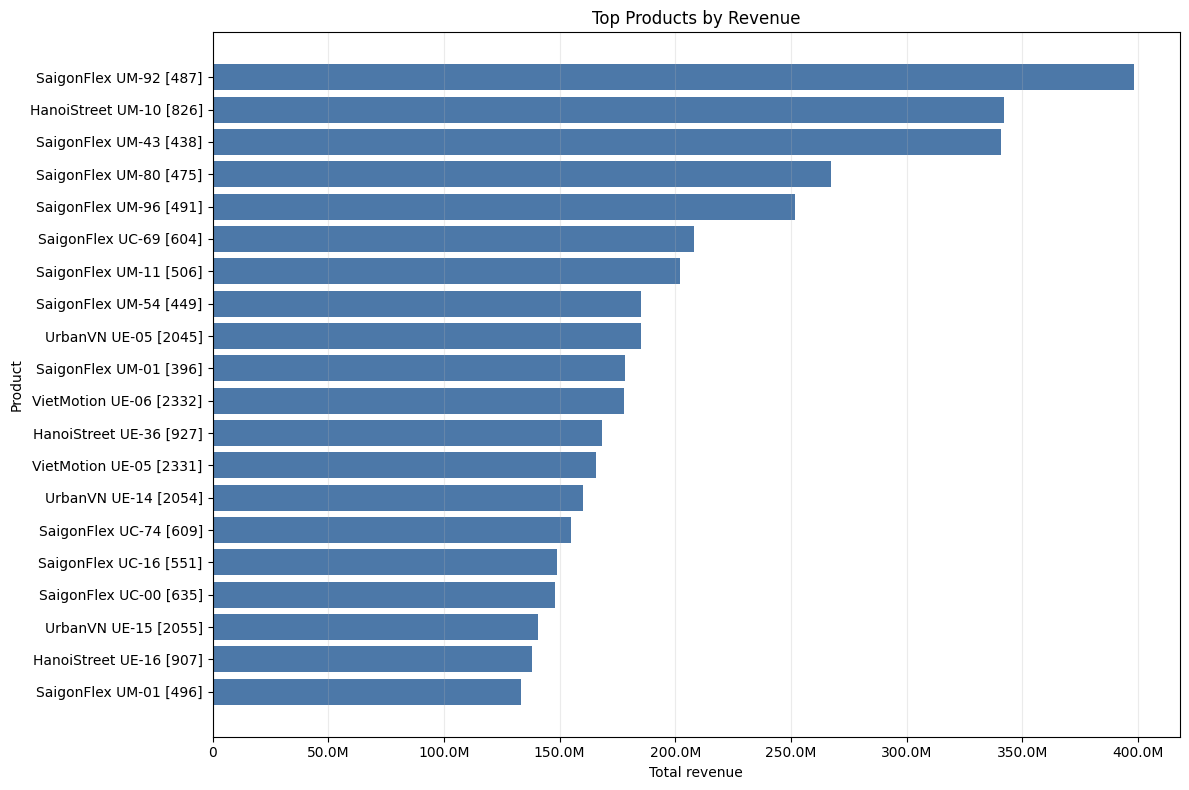

In [6]:
if not analysis_ready:
    print("WARNING: Skipping product revenue contribution because the joined dataset is not available.")
else:
    total_revenue = product_items["revenue"].sum()
    agg_kwargs = dict(
        product_name=("product_name", "first"),
        total_revenue=("revenue", "sum"),
        number_of_orders=("order_id", "nunique"),
        number_of_order_items=("revenue", "size"),
        average_revenue_per_order_item=("revenue", "mean"),
    )
    if "quantity" in product_items.columns:
        agg_kwargs["total_quantity_sold"] = ("quantity", "sum")
    product_revenue = (
        product_items.groupby("product_id", dropna=False)
        .agg(**agg_kwargs)
        .sort_values("total_revenue", ascending=False)
        .reset_index()
    )
    product_revenue["revenue_share"] = product_revenue["total_revenue"] / total_revenue if total_revenue else np.nan
    product_revenue["cumulative_revenue_share"] = product_revenue["revenue_share"].cumsum()
    product_revenue["rank_by_revenue"] = np.arange(1, len(product_revenue) + 1)
    product_revenue["product_label"] = product_revenue["product_name"].astype(str) + " [" + product_revenue["product_id"].astype(str) + "]"

    print("Top 20 products by revenue")
    display(product_revenue.head(20))
    print("Bottom 20 products by revenue")
    display(product_revenue.tail(20).sort_values("total_revenue", ascending=True))

    plot_df = product_revenue.head(20).sort_values("total_revenue", ascending=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(plot_df["product_label"], plot_df["total_revenue"], color="#4C78A8")
    ax.set_title("Top Products by Revenue")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Product")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Pareto analysis

Calculate revenue share contributed by the top 1%, 5%, 10%, and 20% of products and how many products are needed to explain 50%, 80%, and 90% of revenue.

In [7]:
def share_for_top_product_fraction(df, fraction):
    if df.empty:
        return np.nan, 0
    n = max(1, int(np.ceil(len(df) * fraction)))
    return df.head(n)["revenue_share"].sum(), n


def products_needed_for_share(df, threshold):
    eligible = df.loc[df["cumulative_revenue_share"] >= threshold]
    return int(eligible.iloc[0]["rank_by_revenue"]) if not eligible.empty else np.nan


if not analysis_ready or product_revenue.empty:
    print("WARNING: Skipping Pareto analysis because product revenue is not available.")
else:
    rows = []
    for fraction in [0.01, 0.05, 0.10, 0.20]:
        share, n_products = share_for_top_product_fraction(product_revenue, fraction)
        rows.append({
            "product_group": f"top_{int(fraction * 100)}pct_products",
            "products_in_group": n_products,
            "revenue_share": share,
        })
    products_for_50 = products_needed_for_share(product_revenue, 0.50)
    products_for_80 = products_needed_for_share(product_revenue, 0.80)
    products_for_90 = products_needed_for_share(product_revenue, 0.90)
    top_20pct_revenue_share = rows[-1]["revenue_share"]

    pareto_summary_df = pd.DataFrame(rows)
    threshold_summary_df = pd.DataFrame([{
        "total_products": len(product_revenue),
        "products_needed_for_50pct_revenue": products_for_50,
        "products_needed_for_80pct_revenue": products_for_80,
        "products_needed_for_90pct_revenue": products_for_90,
        "top_20pct_product_revenue_share": top_20pct_revenue_share,
    }])

    if pd.notna(top_20pct_revenue_share) and top_20pct_revenue_share >= 0.80:
        concentration_statement = f"Revenue shows a strong Pareto pattern: top 20% of products contribute {top_20pct_revenue_share:.1%} of revenue."
    elif pd.notna(top_20pct_revenue_share) and top_20pct_revenue_share >= 0.60:
        concentration_statement = f"Revenue is moderately concentrated: top 20% of products contribute {top_20pct_revenue_share:.1%} of revenue."
    else:
        concentration_statement = f"Revenue is more distributed across products: top 20% contribute {top_20pct_revenue_share:.1%} of revenue."

    display(pareto_summary_df)
    display(threshold_summary_df)
    print(concentration_statement)

,product_group,products_in_group,revenue_share
0,top_1pct_products,16,0.215127
1,top_5pct_products,80,0.499896
2,top_10pct_products,160,0.654956
3,top_20pct_products,320,0.818351


,total_products,products_needed_for_50pct_revenue,products_needed_for_80pct_revenue,products_needed_for_90pct_revenue,top_20pct_product_revenue_share
0,1598,81,295,488,0.818351


Revenue shows a strong Pareto pattern: top 20% of products contribute 81.8% of revenue.


## 8. Revenue concentration metrics

Compute top-N product revenue shares and a Herfindahl-Hirschman style concentration score based on product revenue share.

In [8]:
if not analysis_ready or product_revenue.empty:
    print("WARNING: Skipping concentration metrics because product revenue is not available.")
else:
    top_product_share_summary = {
        "top_1_product_revenue_share": product_revenue.head(1)["revenue_share"].sum(),
        "top_5_products_revenue_share": product_revenue.head(5)["revenue_share"].sum(),
        "top_10_products_revenue_share": product_revenue.head(10)["revenue_share"].sum(),
        "top_20_products_revenue_share": product_revenue.head(20)["revenue_share"].sum(),
        "product_revenue_hhi": float((product_revenue["revenue_share"] ** 2).sum()),
        "effective_number_of_products_hhi_inverse": float(1 / (product_revenue["revenue_share"] ** 2).sum()) if (product_revenue["revenue_share"] ** 2).sum() > 0 else np.nan,
    }
    concentration_metrics_df = pd.DataFrame([top_product_share_summary])
    display(concentration_metrics_df)

,top_1_product_revenue_share,top_5_products_revenue_share,top_10_products_revenue_share,top_20_products_revenue_share,product_revenue_hhi,effective_number_of_products_hhi_inverse
0,0.024236,0.097404,0.155728,0.249216,0.005223,191.468546


## 9. Pareto and cumulative contribution charts

Visualize ranked product revenue and cumulative revenue contribution. The bar chart is limited to top products for readability, while the cumulative curve uses all products.

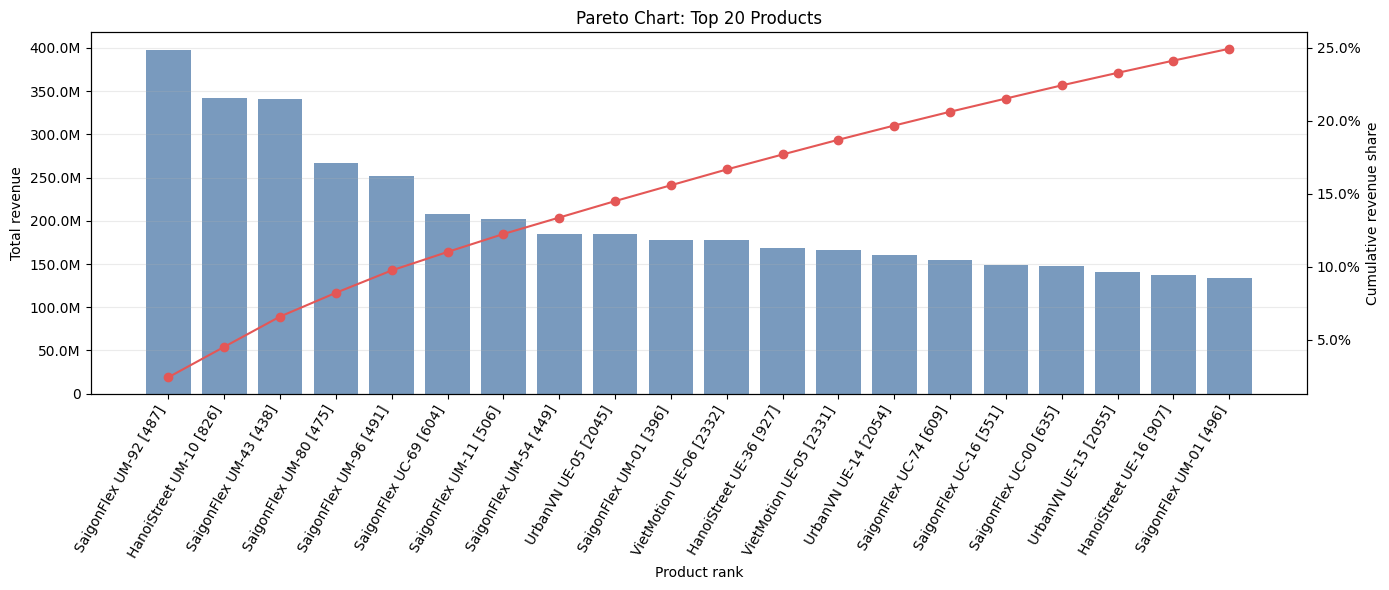

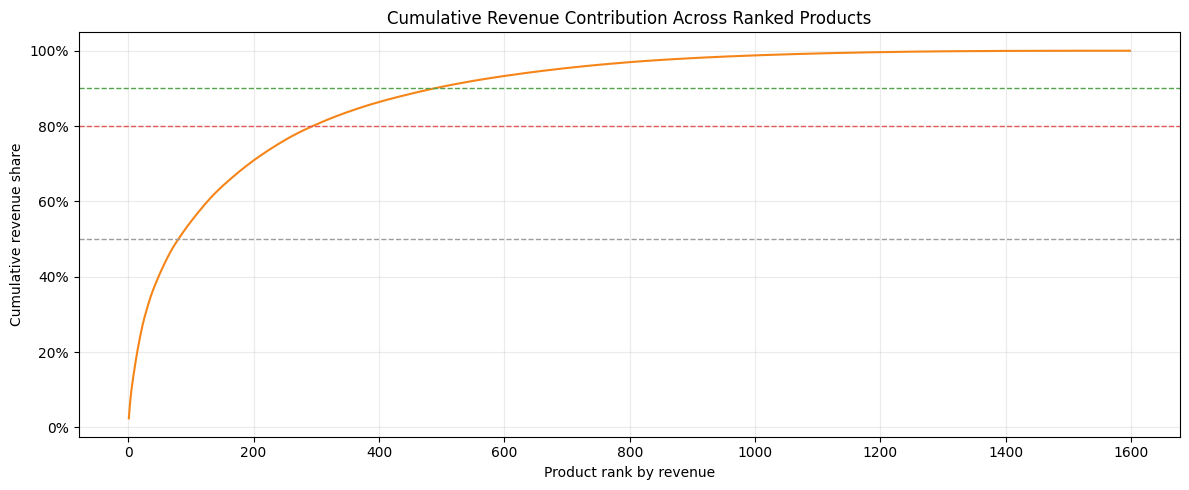

In [9]:
if not analysis_ready or product_revenue.empty:
    print("WARNING: Skipping Pareto charts because product revenue is not available.")
else:
    top_plot_df = product_revenue.head(TOP_N_PRODUCTS_FOR_CHARTS).copy()
    fig, ax1 = plt.subplots(figsize=(14, 6))
    x = np.arange(len(top_plot_df))
    ax1.bar(x, top_plot_df["total_revenue"], color="#4C78A8", alpha=0.75)
    ax1.set_xlabel("Product rank")
    ax1.set_ylabel("Total revenue")
    ax1.yaxis.set_major_formatter(currency_axis)
    ax2 = ax1.twinx()
    ax2.plot(x, top_plot_df["cumulative_revenue_share"], color="#E45756", marker="o", linewidth=1.5)
    ax2.set_ylabel("Cumulative revenue share")
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.set_title(f"Pareto Chart: Top {len(top_plot_df)} Products")
    ax1.set_xticks(x)
    ax1.set_xticklabels(top_plot_df["product_label"], rotation=60, ha="right")
    ax1.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(product_revenue["rank_by_revenue"], product_revenue["cumulative_revenue_share"], color="#F58518", linewidth=1.5)
    ax.axhline(0.50, color="#9D9D9D", linestyle="--", linewidth=1)
    ax.axhline(0.80, color="#E45756", linestyle="--", linewidth=1)
    ax.axhline(0.90, color="#54A24B", linestyle="--", linewidth=1)
    ax.set_title("Cumulative Revenue Contribution Across Ranked Products")
    ax.set_xlabel("Product rank by revenue")
    ax.set_ylabel("Cumulative revenue share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 10. Top-product stability over time

Aggregate product revenue by month, identify monthly top products, and inspect whether the same products repeatedly appear in the top 10 or top 20.

Products most frequently appearing in monthly top 10/top 20


,product_id,product_name,months_observed,months_in_top_10,months_in_top_20,average_monthly_revenue,max_monthly_revenue,share_observed_months_top_10,share_observed_months_top_20
566,826,HanoiStreet UM-10,126,105,124,2.716389e+06,7971054.77,0.833333,0.984127
312,491,SaigonFlex UM-96,121,63,76,2.081127e+06,9038705.96,0.520661,0.628099
272,438,SaigonFlex UM-43,80,61,61,4.258828e+06,11293315.58,0.762500,0.762500
308,487,SaigonFlex UM-92,72,60,63,5.530744e+06,15573456.34,0.833333,0.875000
234,396,SaigonFlex UM-01,58,48,48,3.072447e+06,7928189.55,0.827586,0.827586
298,475,SaigonFlex UM-80,63,47,49,4.244246e+06,12533071.75,0.746032,0.777778
243,407,SaigonFlex UM-12,53,44,50,2.507911e+06,5715699.06,0.830189,0.943396
327,506,SaigonFlex UM-11,42,41,41,4.805326e+06,9792150.53,0.976190,0.976190
317,496,SaigonFlex UM-01,70,40,57,1.904095e+06,6617056.51,0.571429,0.814286
436,635,SaigonFlex UC-00,64,37,49,2.315409e+06,6977120.13,0.578125,0.765625


Products that were stronger early but declined later


,product_id,product_name,early_avg_monthly_revenue,late_avg_monthly_revenue,late_minus_early,late_vs_early_pct,total_revenue,rank_by_revenue
298,475,SaigonFlex UM-80,4.241304e+06,2.941844e+03,-4.238362e+06,-99.930638,2.673875e+08,4
234,396,SaigonFlex UM-01,2.828602e+06,0.000000e+00,-2.828602e+06,-100.000000,1.782019e+08,10
366,551,SaigonFlex UC-16,2.360312e+06,1.993894e+03,-2.358318e+06,-99.915524,1.488253e+08,16
436,635,SaigonFlex UC-00,2.348739e+06,3.422817e+03,-2.345316e+06,-99.854270,1.481862e+08,17
566,826,HanoiStreet UM-10,3.644888e+06,1.787890e+06,-1.856998e+06,-50.948022,3.422650e+08,2
410,604,SaigonFlex UC-69,2.558664e+06,7.418226e+05,-1.816841e+06,-71.007425,2.079307e+08,6
277,445,SaigonFlex UM-50,1.526655e+06,1.045205e+03,-1.525610e+06,-99.931536,9.624510e+07,27
320,499,SaigonFlex UM-04,1.435703e+06,3.825932e+03,-1.431877e+06,-99.733515,9.069030e+07,33
458,657,SaigonFlex UC-22,1.394815e+06,0.000000e+00,-1.394815e+06,-100.000000,8.787337e+07,35
1380,2045,UrbanVN UE-05,2.131411e+06,8.063866e+05,-1.325024e+06,-62.166531,1.850812e+08,9


Products that became stronger later


,product_id,product_name,early_avg_monthly_revenue,late_avg_monthly_revenue,late_minus_early,late_vs_early_pct,total_revenue,rank_by_revenue
327,506,SaigonFlex UM-11,0.000000e+00,3.203551e+06,3.203551e+06,NaN,2.018237e+08,7
279,449,SaigonFlex UM-54,0.000000e+00,2.940510e+06,2.940510e+06,NaN,1.852522e+08,8
272,438,SaigonFlex UM-43,1.628418e+06,3.779618e+06,2.151200e+06,132.103645,3.407063e+08,3
243,407,SaigonFlex UM-12,0.000000e+00,2.109830e+06,2.109830e+06,NaN,1.329193e+08,21
308,487,SaigonFlex UM-92,2.200948e+06,4.119902e+06,1.918954e+06,87.187630,3.982136e+08,1
390,578,SaigonFlex UC-43,4.988042e+03,9.320168e+05,9.270288e+05,18585.024219,5.903131e+07,55
420,615,SaigonFlex UC-80,1.715428e+05,9.091655e+05,7.376228e+05,429.993438,6.808463e+07,43
294,470,SaigonFlex UM-75,0.000000e+00,7.159440e+05,7.159440e+05,NaN,4.510447e+07,72
289,461,SaigonFlex UM-66,0.000000e+00,7.143194e+05,7.143194e+05,NaN,4.500212e+07,73
1565,2368,VietMotion UC-16,0.000000e+00,6.825821e+05,6.825821e+05,NaN,4.300267e+07,75


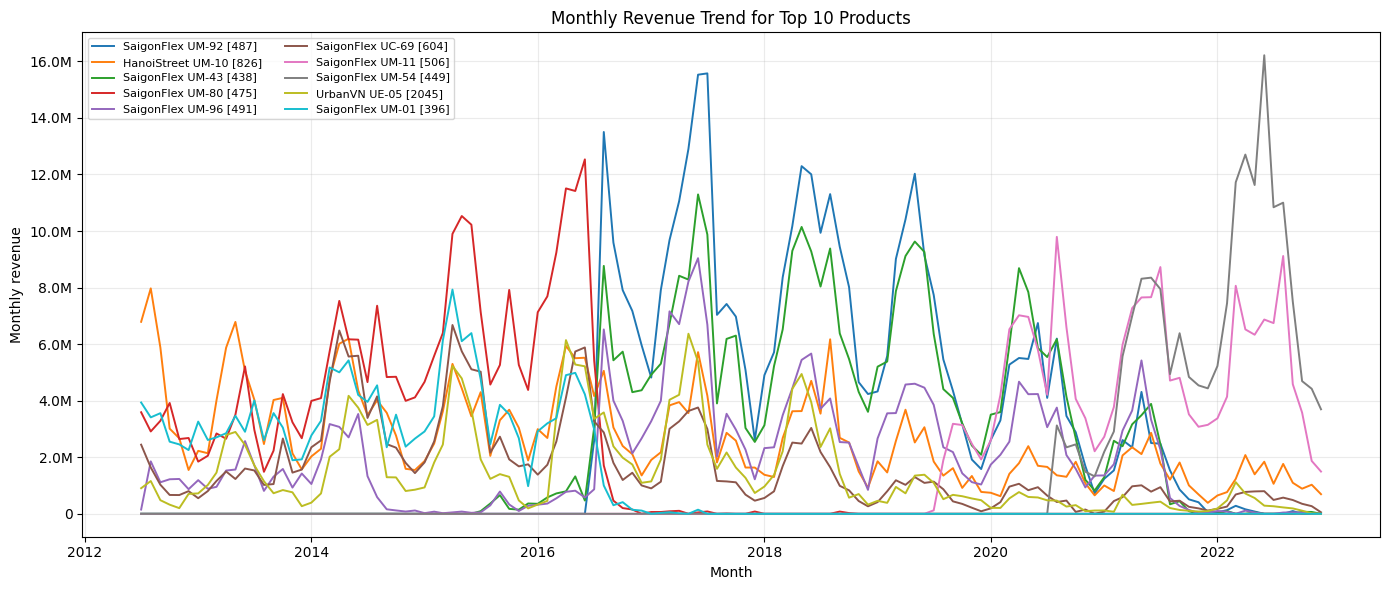

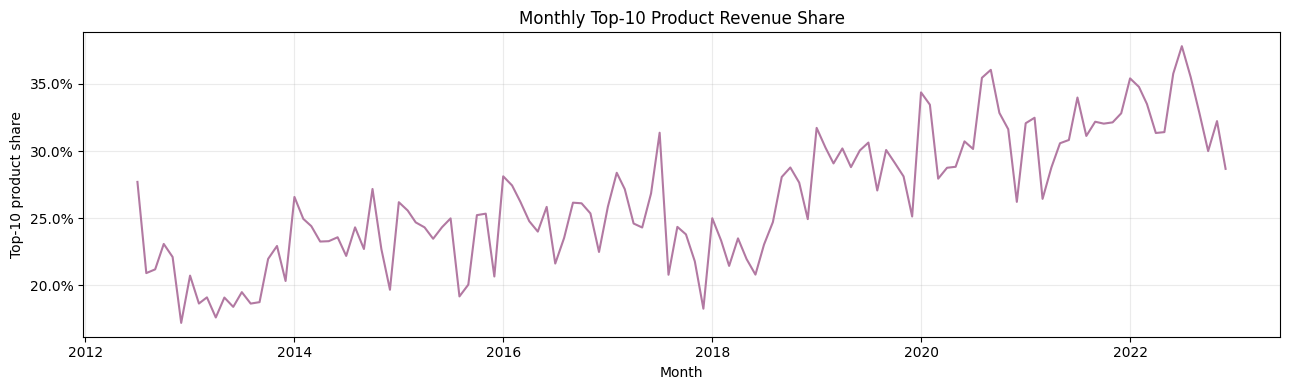

In [10]:
if not analysis_ready or product_revenue.empty:
    print("WARNING: Skipping top-product stability because product revenue is not available.")
else:
    monthly_product = (
        product_items.groupby(["month", "product_id", "product_name"], as_index=False)
        .agg(monthly_revenue=("revenue", "sum"), monthly_orders=("order_id", "nunique"), monthly_items=("revenue", "size"))
    )
    monthly_product["monthly_rank"] = monthly_product.groupby("month")["monthly_revenue"].rank(method="first", ascending=False)
    monthly_product["is_monthly_top_10"] = monthly_product["monthly_rank"] <= 10
    monthly_product["is_monthly_top_20"] = monthly_product["monthly_rank"] <= 20

    top_product_frequency_df = (
        monthly_product.groupby(["product_id", "product_name"], as_index=False)
        .agg(
            months_observed=("month", "nunique"),
            months_in_top_10=("is_monthly_top_10", "sum"),
            months_in_top_20=("is_monthly_top_20", "sum"),
            average_monthly_revenue=("monthly_revenue", "mean"),
            max_monthly_revenue=("monthly_revenue", "max"),
        )
    )
    top_product_frequency_df["share_observed_months_top_10"] = top_product_frequency_df["months_in_top_10"] / top_product_frequency_df["months_observed"].replace(0, np.nan)
    top_product_frequency_df["share_observed_months_top_20"] = top_product_frequency_df["months_in_top_20"] / top_product_frequency_df["months_observed"].replace(0, np.nan)
    top_product_frequency_df = top_product_frequency_df.sort_values(["months_in_top_10", "average_monthly_revenue"], ascending=False)

    full_months = pd.date_range(product_items["month"].min(), product_items["month"].max(), freq="MS")
    monthly_pivot = (
        monthly_product.pivot(index="month", columns="product_id", values="monthly_revenue")
        .reindex(full_months)
        .fillna(0)
    )
    monthly_pivot.index.name = "month"

    first_half = monthly_pivot.iloc[: max(1, len(monthly_pivot) // 2)]
    second_half = monthly_pivot.iloc[max(1, len(monthly_pivot) // 2):]
    early_late_rows = []
    for product_id in monthly_pivot.columns:
        early_avg = first_half[product_id].mean()
        late_avg = second_half[product_id].mean() if len(second_half) else np.nan
        product_name = product_revenue.loc[product_revenue["product_id"] == product_id, "product_name"]
        early_late_rows.append({
            "product_id": product_id,
            "product_name": product_name.iloc[0] if len(product_name) else str(product_id),
            "early_avg_monthly_revenue": early_avg,
            "late_avg_monthly_revenue": late_avg,
            "late_minus_early": late_avg - early_avg if pd.notna(late_avg) else np.nan,
            "late_vs_early_pct": (late_avg - early_avg) / early_avg * 100 if pd.notna(late_avg) and abs(early_avg) > 1e-9 else np.nan,
        })
    early_late_df = pd.DataFrame(early_late_rows)
    meaningful_products = early_late_df.merge(product_revenue[["product_id", "total_revenue", "rank_by_revenue"]], on="product_id", how="left")
    min_revenue_for_trend = product_revenue["total_revenue"].sum() * 0.001
    meaningful_products = meaningful_products.loc[meaningful_products["total_revenue"] >= min_revenue_for_trend]
    declining_products_df = meaningful_products.sort_values("late_minus_early", ascending=True).head(15)
    emerging_products_df = meaningful_products.sort_values("late_minus_early", ascending=False).head(15)

    stable_top_products_text = ", ".join(
        f"{row.product_name} ({int(row.months_in_top_10)} months)"
        for row in top_product_frequency_df.head(5).itertuples()
    )
    declining_products_text = ", ".join(
        f"{row.product_name} ({row.late_minus_early:,.0f})"
        for row in declining_products_df.head(5).itertuples()
    )
    emerging_products_text = ", ".join(
        f"{row.product_name} (+{row.late_minus_early:,.0f})"
        for row in emerging_products_df.head(5).itertuples()
    )

    print("Products most frequently appearing in monthly top 10/top 20")
    display(top_product_frequency_df.head(30))
    print("Products that were stronger early but declined later")
    display(declining_products_df)
    print("Products that became stronger later")
    display(emerging_products_df)

    top_trend_products = product_revenue.head(TOP_N_PRODUCTS_FOR_TRENDS)["product_id"].tolist()
    label_map = product_revenue.set_index("product_id")["product_label"].to_dict()
    fig, ax = plt.subplots(figsize=(14, 6))
    for product_id in top_trend_products:
        ax.plot(monthly_pivot.index, monthly_pivot[product_id], label=label_map.get(product_id, str(product_id)), linewidth=1.4)
    ax.set_title(f"Monthly Revenue Trend for Top {len(top_trend_products)} Products")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    monthly_top_share = monthly_product.loc[monthly_product["is_monthly_top_10"]].groupby("month")["monthly_revenue"].sum() / monthly_product.groupby("month")["monthly_revenue"].sum()
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly_top_share.index, monthly_top_share, color="#B279A2", linewidth=1.5)
    ax.set_title("Monthly Top-10 Product Revenue Share")
    ax.set_xlabel("Month")
    ax.set_ylabel("Top-10 product share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Long-tail product analysis

Segment products into head, mid-tail, and long-tail groups based on cumulative revenue share. This helps assess whether long-tail products still matter through breadth, order count, or optional assortment strategy.

,contribution_group,number_of_products,revenue,average_revenue_per_product,order_item_count,order_count,product_share,revenue_share,order_item_count_share,order_count_share
0,head_products_to_50pct,80,8.213536e+09,1.026692e+08,244441,238802,0.050063,0.499896,0.342034,0.369123
2,mid_tail_50_to_80pct,214,4.927826e+09,2.302722e+07,266009,237355,0.133917,0.299920,0.372213,0.366886
1,long_tail_after_80pct,1304,3.289114e+09,2.522327e+06,204219,176900,0.816020,0.200184,0.285753,0.273439


Long-tail products represent 81.6% of products and 20.0% of revenue.


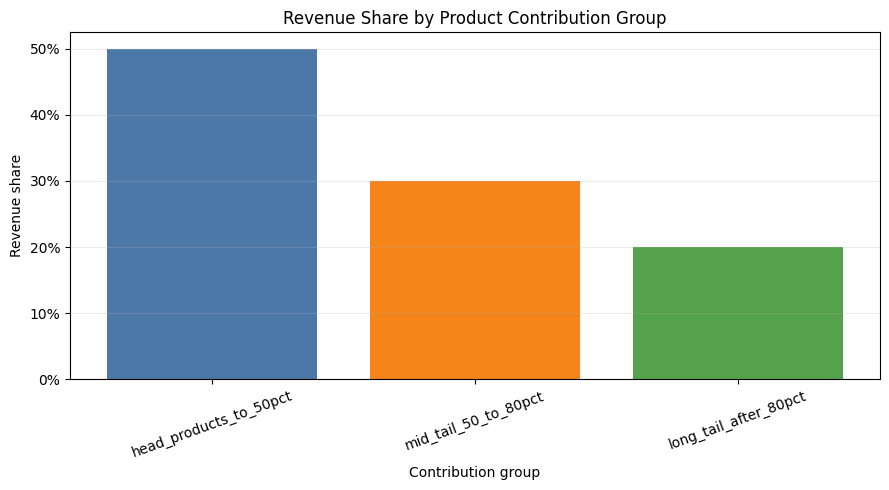

In [11]:
if not analysis_ready or product_revenue.empty:
    print("WARNING: Skipping long-tail analysis because product revenue is not available.")
else:
    def tail_group(cum_share):
        if cum_share <= 0.50:
            return "head_products_to_50pct"
        if cum_share <= 0.80:
            return "mid_tail_50_to_80pct"
        return "long_tail_after_80pct"

    product_revenue["contribution_group"] = product_revenue["cumulative_revenue_share"].map(tail_group)
    product_group_map = product_revenue.set_index("product_id")["contribution_group"].to_dict()
    product_items["contribution_group"] = product_items["product_id"].map(product_group_map).fillna("unknown")

    total_revenue = product_items["revenue"].sum()
    total_items = len(product_items)
    total_orders = product_items["order_id"].nunique()
    long_tail_summary_df = (
        product_revenue.groupby("contribution_group", as_index=False)
        .agg(
            number_of_products=("product_id", "nunique"),
            revenue=("total_revenue", "sum"),
            average_revenue_per_product=("total_revenue", "mean"),
        )
    )
    group_items = (
        product_items.groupby("contribution_group", as_index=False)
        .agg(order_item_count=("revenue", "size"), order_count=("order_id", "nunique"))
    )
    long_tail_summary_df = long_tail_summary_df.merge(group_items, on="contribution_group", how="left")
    long_tail_summary_df["product_share"] = long_tail_summary_df["number_of_products"] / len(product_revenue)
    long_tail_summary_df["revenue_share"] = long_tail_summary_df["revenue"] / total_revenue if total_revenue else np.nan
    long_tail_summary_df["order_item_count_share"] = long_tail_summary_df["order_item_count"] / total_items if total_items else np.nan
    long_tail_summary_df["order_count_share"] = long_tail_summary_df["order_count"] / total_orders if total_orders else np.nan
    long_tail_summary_df = long_tail_summary_df.sort_values("revenue_share", ascending=False)

    long_tail_row = long_tail_summary_df.loc[long_tail_summary_df["contribution_group"] == "long_tail_after_80pct"]
    if not long_tail_row.empty:
        long_tail_statement = (
            f"Long-tail products represent {long_tail_row.iloc[0]['product_share']:.1%} of products "
            f"and {long_tail_row.iloc[0]['revenue_share']:.1%} of revenue."
        )
    else:
        long_tail_statement = "No long-tail group was identified."

    display(long_tail_summary_df)
    print(long_tail_statement)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(long_tail_summary_df["contribution_group"], long_tail_summary_df["revenue_share"], color=["#4C78A8", "#F58518", "#54A24B"][:len(long_tail_summary_df)])
    ax.set_title("Revenue Share by Product Contribution Group")
    ax.set_xlabel("Contribution group")
    ax.set_ylabel("Revenue share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 12. Leakage-safe product-concentration feature preview

Create daily feature examples using only historical product revenue. Product revenue is shifted before top-product shares, concentration, entropy, and count features are calculated.

In [12]:
def entropy_from_shares(row):
    values = row.dropna()
    values = values[values > 0]
    if values.empty:
        return np.nan
    return float(-(values * np.log(values)).sum())


if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because the joined product dataset is not available.")
else:
    daily_product = (
        product_items.groupby(["order_date", "product_id"], as_index=False)
        .agg(revenue=("revenue", "sum"))
    )
    daily_pivot = daily_product.pivot(index="order_date", columns="product_id", values="revenue").fillna(0)
    full_days = pd.date_range(daily_pivot.index.min(), daily_pivot.index.max(), freq="D")
    daily_pivot = daily_pivot.reindex(full_days).fillna(0)
    daily_pivot.index.name = "date"
    daily_total = daily_pivot.sum(axis=1)

    shifted_product = daily_pivot.shift(1)
    rolling_product_30 = shifted_product.rolling(window=30, min_periods=7).sum()
    rolling_total_30 = rolling_product_30.sum(axis=1)
    rolling_shares_30 = rolling_product_30.div(rolling_total_30.replace(0, np.nan), axis=0)
    sorted_share_values = np.sort(rolling_shares_30.fillna(0).to_numpy(), axis=1)[:, ::-1]
    top_1_share = sorted_share_values[:, :1].sum(axis=1)
    top_5_share = sorted_share_values[:, :5].sum(axis=1)
    top_10_share = sorted_share_values[:, :10].sum(axis=1)
    concentration_index = (rolling_shares_30.fillna(0) ** 2).sum(axis=1)
    entropy = rolling_shares_30.apply(entropy_from_shares, axis=1)
    top_product_revenue_lag = shifted_product.max(axis=1)
    top_product_count_lag = (rolling_product_30 > 0).sum(axis=1)

    feature_df = pd.DataFrame({
        "date": daily_pivot.index,
        "total_revenue": daily_total.values,
        "top_product_revenue_share_lag": top_1_share,
        "top_5_product_revenue_share_lag": top_5_share,
        "top_10_product_revenue_share_lag": top_10_share,
        "product_concentration_index_lag": concentration_index.values,
        "product_mix_entropy_lag": entropy.values,
        "top_product_revenue_lag": top_product_revenue_lag.values,
        "top_product_count_lag": top_product_count_lag.values,
    })
    feature_preview = feature_df.dropna(subset=["top_product_revenue_share_lag"]).head(20)
    if feature_preview.empty:
        feature_preview = feature_df.head(20)
    display(feature_preview)
    print("Leakage-safe construction: daily product revenue is shifted by one day before rolling concentration features are computed.")
    print(forecast_feature_warning)
    print("Recommended product-concentration forecast features:", ", ".join(recommended_product_features))

,date,total_revenue,top_product_revenue_share_lag,top_5_product_revenue_share_lag,top_10_product_revenue_share_lag,product_concentration_index_lag,product_mix_entropy_lag,top_product_revenue_lag,top_product_count_lag
0,2012-07-04,5123547.94,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0
1,2012-07-05,2751773.45,0.000000,0.000000,0.000000,0.000000,NaN,405332.43,0
2,2012-07-06,3054029.42,0.000000,0.000000,0.000000,0.000000,NaN,276183.70,0
3,2012-07-07,2667930.94,0.000000,0.000000,0.000000,0.000000,NaN,301716.62,0
4,2012-07-08,2360851.90,0.000000,0.000000,0.000000,0.000000,NaN,282558.84,0
5,2012-07-09,3548386.46,0.000000,0.000000,0.000000,0.000000,NaN,244994.48,0
6,2012-07-10,5234938.62,0.000000,0.000000,0.000000,0.000000,NaN,286557.12,0
7,2012-07-11,5582884.78,0.061846,0.244996,0.398326,0.021167,4.528933,345704.71,246
8,2012-07-12,5734632.02,0.057067,0.233496,0.382353,0.019557,4.610931,316682.42,264
9,2012-07-13,5309511.71,0.050716,0.207845,0.350583,0.016905,4.737315,255652.71,283


Leakage-safe construction: daily product revenue is shifted by one day before rolling concentration features are computed.
Future product mix and future top-product composition must not be used directly for forecasting unless separately forecasted.
Recommended product-concentration forecast features: top_product_revenue_share_lag, top_5_product_revenue_share_lag, top_10_product_revenue_share_lag, product_concentration_index_lag, product_mix_entropy_lag, top_product_revenue_lag, top_product_count_lag


## 13. Key observations and warnings

Summarize product concentration, Pareto contribution, stability, long-tail interpretation, business implications, and leakage-safe feature recommendations.

In [13]:
if analysis_ready and not product_revenue.empty:
    top_1_product_share = top_product_share_summary.get("top_1_product_revenue_share", np.nan)
    top_5_product_share = top_product_share_summary.get("top_5_products_revenue_share", np.nan)
    top_10_product_share = top_product_share_summary.get("top_10_products_revenue_share", np.nan)
    top_20_product_share = top_product_share_summary.get("top_20_products_revenue_share", np.nan)

    if not long_tail_summary_df.empty:
        long_tail_text = "; ".join(
            f"{row.contribution_group}: {int(row.number_of_products)} products, {row.revenue_share:.1%} revenue"
            for row in long_tail_summary_df.itertuples()
        )
    else:
        long_tail_text = long_tail_statement

    inventory_implications = (
        "Prioritize service levels for stable top contributors; monitor emerging products for inventory allocation; "
        "use long-tail products for breadth carefully because their combined revenue share is limited."
    )
    marketing_implications = (
        "Stable top products can anchor campaigns, while declining former top products may need diagnosis or targeted support."
    )

    print("Insight summary")
    print(f"- Top 20% of products revenue share: {top_20pct_revenue_share:.1%}")
    print(f"- Top 1 / 5 / 10 / 20 product revenue share: {top_1_product_share:.1%} / {top_5_product_share:.1%} / {top_10_product_share:.1%} / {top_20_product_share:.1%}")
    print(f"- Products needed for 50% / 80% / 90% revenue: {products_for_50} / {products_for_80} / {products_for_90}")
    print(f"- Concentration interpretation: {concentration_statement}")
    print(f"- Most stable top products over time: {stable_top_products_text}")
    print(f"- Products with declining contribution: {declining_products_text}")
    print(f"- Products with emerging contribution: {emerging_products_text}")
    print(f"- Head / mid-tail / long-tail interpretation: {long_tail_text}")
    print(f"- Inventory implication: {inventory_implications}")
    print(f"- Marketing implication: {marketing_implications}")
    print(f"- Recommended leakage-safe product-concentration forecast features: {', '.join(recommended_product_features)}")
    print(f"- Forecasting warning: {forecast_feature_warning}")
else:
    print("Insight summary")
    print("- Product concentration analysis could not be completed because required joined data was not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Top 20% of products revenue share: 81.8%
- Top 1 / 5 / 10 / 20 product revenue share: 2.4% / 9.7% / 15.6% / 24.9%
- Products needed for 50% / 80% / 90% revenue: 81 / 295 / 488
- Concentration interpretation: Revenue shows a strong Pareto pattern: top 20% of products contribute 81.8% of revenue.
- Most stable top products over time: HanoiStreet UM-10 (105 months), SaigonFlex UM-96 (63 months), SaigonFlex UM-43 (61 months), SaigonFlex UM-92 (60 months), SaigonFlex UM-01 (48 months)
- Products with declining contribution: SaigonFlex UM-80 (-4,238,362), SaigonFlex UM-01 (-2,828,602), SaigonFlex UC-16 (-2,358,318), SaigonFlex UC-00 (-2,345,316), HanoiStreet UM-10 (-1,856,998)
- Products with emerging contribution: SaigonFlex UM-11 (+3,203,551), SaigonFlex UM-54 (+2,940,510), SaigonFlex UM-43 (+2,151,200), SaigonFlex UM-12 (+2,109,830), SaigonFlex UM-92 (+1,918,954)
- Head / mid-tail / long-tail interpretation: head_products_to_50pct: 80 products, 50.0% revenue; mid_tail_50